<a href="https://colab.research.google.com/github/steve1419/IBM_Online/blob/main/BRIN_BTREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 * Starting PostgreSQL 14 database server
   ...done.
ALTER ROLE
Cloning into 'tpch-dbgen'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 138 (delta 25), reused 118 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 217.08 KiB | 9.87 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/tpch-dbgen
gcc -g -DDBNAME=\"dss\" -DMAC -DORACLE -DTPCH -DRNG_TEST -D_FILE_OFFSET_BITS=64    -c -o build.o build.c
In file included from dss.h:81,
                 from build.c:45:
config.h:151: warning: "_POSIX_C_SOURCE" redefined
  151 | #define _POSIX_C_SOURCE 200112L
      | 
In file included from /usr/include/x86_64-linux-gnu/bits/libc-header-start.h:33,
                 from /usr

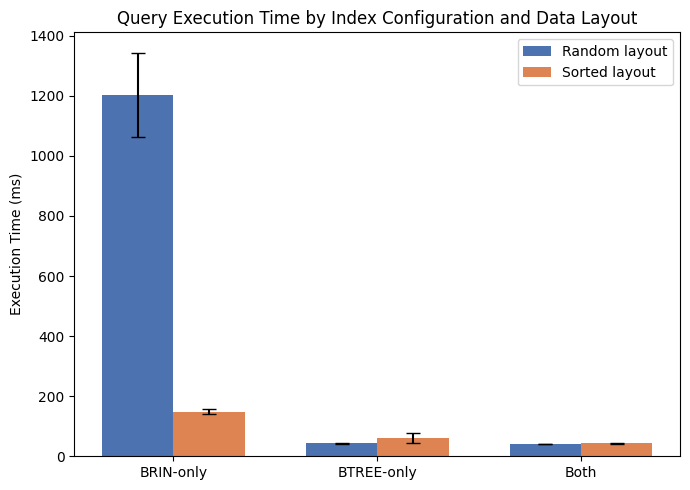

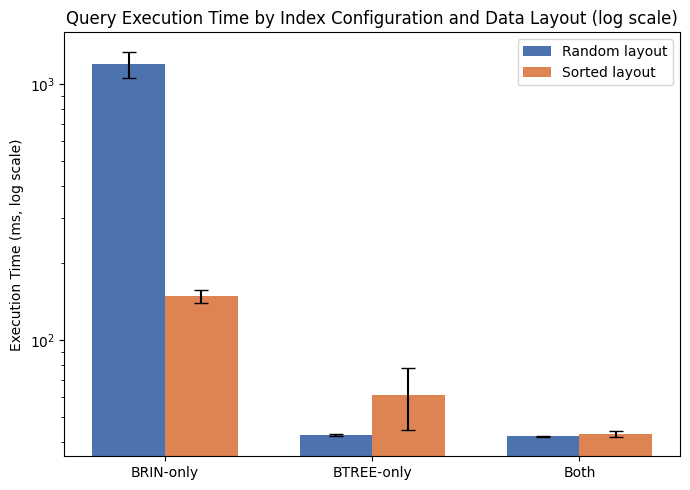

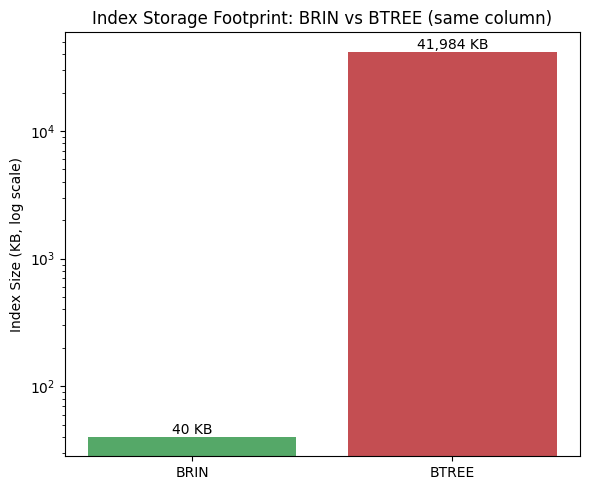

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================================================
# BRIN vs BTREE vs Coexisting Index Benchmark — TPC-H lineitem (SF1)
# Run this top-to-bottom in Google Colab. Each "# %%" marks a natural cell
# break if you paste sections into separate Colab cells.
# Total runtime: ~10-15 minutes (dbgen build + 6M-row load + 18 EXPLAIN runs).
# ==========================================================================

# %% [1] Install PostgreSQL and build tools inside the Colab VM
!apt-get -qq update
!apt-get -qq install -y postgresql postgresql-contrib build-essential git > /dev/null
!service postgresql start

# %% [2] Create the database and a password-auth superuser role
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"
!sudo -u postgres createdb tpch_test

# %% [3] Build the official TPC-H data generator (dbgen) and generate SF1 lineitem
!git clone --depth 1 https://github.com/electrum/tpch-dbgen.git
%cd tpch-dbgen
!cp makefile.suite Makefile
!sed -i 's/^CC .*=.*/CC = gcc/' Makefile
!sed -i 's/^DATABASE.*=.*/DATABASE = POSTGRESQL/' Makefile
!sed -i 's/^MACHINE.*=.*/MACHINE = LINUX/' Makefile
!sed -i 's/^WORKLOAD.*=.*/WORKLOAD = TPCH/' Makefile
!make
# -s 1 = scale factor 1 (~6,001,215 lineitem rows); -T L = lineitem table only
!./dbgen -s 1 -T L -f
!sed -i 's/|$//' lineitem.tbl   # strip dbgen's trailing pipe delimiter
!wc -l lineitem.tbl
%cd ..

# %% [4] Load into PostgreSQL and build the two physical layouts
import subprocess

def run_psql(sql, db="tpch_test"):
    """Run a SQL string against tpch_test as the postgres OS user and return stdout."""
    result = subprocess.run(
        ["sudo", "-u", "postgres", "psql", "-d", db, "-c", sql],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
    return result.stdout

ddl = """
DROP TABLE IF EXISTS lineitem_stage, lineitem_sorted, lineitem_random;
CREATE TABLE lineitem_stage (
    l_orderkey bigint, l_partkey bigint, l_suppkey bigint, l_linenumber integer,
    l_quantity numeric(15,2), l_extendedprice numeric(15,2), l_discount numeric(15,2),
    l_tax numeric(15,2), l_returnflag char(1), l_linestatus char(1),
    l_shipdate date, l_commitdate date, l_receiptdate date,
    l_shipinstruct char(25), l_shipmode char(10), l_comment varchar(44)
);
"""
print(run_psql(ddl))

!sudo -u postgres psql -d tpch_test -c "\\COPY lineitem_stage FROM 'tpch-dbgen/lineitem.tbl' WITH (FORMAT csv, DELIMITER '|');"

layout_sql = """
CREATE TABLE lineitem_sorted AS SELECT * FROM lineitem_stage ORDER BY l_shipdate;
CREATE TABLE lineitem_random AS SELECT * FROM lineitem_stage ORDER BY random();
DROP TABLE lineitem_stage;
VACUUM ANALYZE lineitem_sorted;
VACUUM ANALYZE lineitem_random;
"""
for stmt in layout_sql.strip().split(";"):
    if stmt.strip():
        print(run_psql(stmt + ";"))

# Sanity check: verify physical clustering actually differs before trusting any timing result
print(run_psql("""
SELECT tablename, correlation FROM pg_stats
WHERE tablename IN ('lineitem_sorted','lineitem_random') AND attname='l_shipdate';
"""))

# %% [5] Helper to run EXPLAIN (ANALYZE, BUFFERS) N times and pull out Execution Time
import re
import statistics

QUERY = """EXPLAIN (ANALYZE, BUFFERS) SELECT COUNT(*) FROM {table}
WHERE l_shipdate BETWEEN '1995-01-01' AND '1995-03-31';"""

def timed_runs(table, n=3):
    times = []
    plans = []
    for _ in range(n):
        out = run_psql(QUERY.format(table=table))
        m = re.search(r"Execution Time:\s*([\d.]+)\s*ms", out)
        if m:
            times.append(float(m.group(1)))
        plans.append(out)
    return times, plans

def index_size(indexname):
    out = run_psql(f"SELECT pg_size_pretty(pg_relation_size('{indexname}'));")
    lines = [l.strip() for l in out.splitlines() if l.strip() and "pg_size_pretty" not in l and "-" not in l.replace("kB","").replace("MB","")]
    return lines[0] if lines else "?"

# %% [6] Run all six configurations: {random, sorted} x {BRIN-only, BTREE-only, both}
results = {}

for table, layout in [("lineitem_random", "random"), ("lineitem_sorted", "sorted")]:
    # --- BRIN only ---
    run_psql(f"DROP INDEX IF EXISTS idx_{layout}_btree;")
    run_psql(f"CREATE INDEX idx_{layout}_brin ON {table} USING brin (l_shipdate);")
    t, _ = timed_runs(table)
    results[(layout, "BRIN-only")] = t
    print(layout, "BRIN-only", t)

    # --- BTREE only ---
    run_psql(f"DROP INDEX IF EXISTS idx_{layout}_brin;")
    run_psql(f"CREATE INDEX idx_{layout}_btree ON {table} USING btree (l_shipdate);")
    t, _ = timed_runs(table)
    results[(layout, "BTREE-only")] = t
    print(layout, "BTREE-only", t)

    # --- Both coexisting (the only real "combined" BRIN+BTREE test) ---
    run_psql(f"CREATE INDEX idx_{layout}_brin ON {table} USING brin (l_shipdate);")
    t, _ = timed_runs(table)
    results[(layout, "Both")] = t
    print(layout, "Both", t)

# Index sizes (kept as strings like "40 kB" / "41 MB" from Postgres)
brin_size = run_psql("SELECT pg_size_pretty(pg_relation_size('idx_random_brin'));")
btree_size = run_psql("SELECT pg_size_pretty(pg_relation_size('idx_random_btree'));")
print("BRIN index size:", brin_size)
print("BTREE index size:", btree_size)

# %% [7] Summarize into a table (mean +/- SD) — this is what should go in the paper
summary = {}
for key, times in results.items():
    summary[key] = (statistics.mean(times), statistics.stdev(times) if len(times) > 1 else 0.0)

for key, (mean, sd) in summary.items():
    print(f"{key}: {mean:.2f} ms +/- {sd:.2f} ms")

# %% [8] Figure 1 — Execution time comparison, grouped bar chart (random vs sorted)
import matplotlib.pyplot as plt
import numpy as np

configs = ["BRIN-only", "BTREE-only", "Both"]
random_means = [summary[("random", c)][0] for c in configs]
random_sds   = [summary[("random", c)][1] for c in configs]
sorted_means = [summary[("sorted", c)][0] for c in configs]
sorted_sds   = [summary[("sorted", c)][1] for c in configs]

x = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, random_means, width, yerr=random_sds, capsize=5, label="Random layout", color="#4C72B0")
ax.bar(x + width/2, sorted_means, width, yerr=sorted_sds, capsize=5, label="Sorted layout", color="#DD8452")
ax.set_ylabel("Execution Time (ms)")
ax.set_title("Query Execution Time by Index Configuration and Data Layout")
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
plt.tight_layout()
plt.savefig("fig1_execution_time.png", dpi=200)
plt.show()

# %% [9] Figure 2 — same data on a log scale (random/BRIN-only dwarfs everything else linearly)
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, random_means, width, yerr=random_sds, capsize=5, label="Random layout", color="#4C72B0")
ax.bar(x + width/2, sorted_means, width, yerr=sorted_sds, capsize=5, label="Sorted layout", color="#DD8452")
ax.set_yscale("log")
ax.set_ylabel("Execution Time (ms, log scale)")
ax.set_title("Query Execution Time by Index Configuration and Data Layout (log scale)")
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
plt.tight_layout()
plt.savefig("fig2_execution_time_logscale.png", dpi=200)
plt.show()

# %% [10] Figure 3 — Index storage footprint (BRIN vs BTREE), log scale, in KB
import re as _re

def size_to_kb(size_str):
    """Parse a Postgres pg_size_pretty string like '40 kB' or '41 MB' into KB."""
    m = _re.search(r"([\d.]+)\s*(kB|MB|GB|bytes)", size_str)
    if not m:
        return None
    val, unit = float(m.group(1)), m.group(2)
    return {"bytes": val / 1024, "kB": val, "MB": val * 1024, "GB": val * 1024 * 1024}[unit]

brin_kb = size_to_kb(brin_size) or 40
btree_kb = size_to_kb(btree_size) or 41 * 1024

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["BRIN", "BTREE"], [brin_kb, btree_kb], color=["#55A868", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Index Size (KB, log scale)")
ax.set_title("Index Storage Footprint: BRIN vs BTREE (same column)")
for b, v in zip(bars, [brin_kb, btree_kb]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f} KB", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("fig3_index_size.png", dpi=200)
plt.show()

# %% [11] Download the figures to insert into the Word document
from google.colab import files
for f in ["fig1_execution_time.png", "fig2_execution_time_logscale.png", "fig3_index_size.png"]:
    files.download(f)

# ==========================================================================
# Notes:
# - Re-running this in Colab will regenerate all data from scratch using the
#   official TPC-H dbgen tool, so exact millisecond values will vary slightly
#   run to run (different VM, different CPU/disk) — that's expected and is
#   itself worth reporting as a limitation, not something to hide.
# - correlation values printed in step [4] should be ~1.0 for lineitem_sorted
#   and ~0.0 for lineitem_random. If they aren't, something went wrong with
#   the table build and the results below shouldn't be trusted.
# - If a step fails partway through, you can re-run from step [4] onward
#   without repeating the dbgen build in step [3].
# ==========================================================================

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 * Starting PostgreSQL 14 database server
   ...done.
ALTER ROLE
Cloning into 'tpch-dbgen'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 138 (delta 25), reused 118 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 217.08 KiB | 4.62 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/tpch-dbgen
gcc -g -DDBNAME=\"dss\" -DMAC -DORACLE -DTPCH -DRNG_TEST -D_FILE_OFFSET_BITS=64    -c -o build.o build.c
In file included from dss.h:81,
                 from build.c:45:
config.h:151: warning: "_POSIX_C_SOURCE" redefined
  151 | #define _POSIX_C_SOURCE 200112L
      | 
In file included from /usr/include/x86_64-linux-gnu/bits/libc-header-start.h:33,
                 from /usr

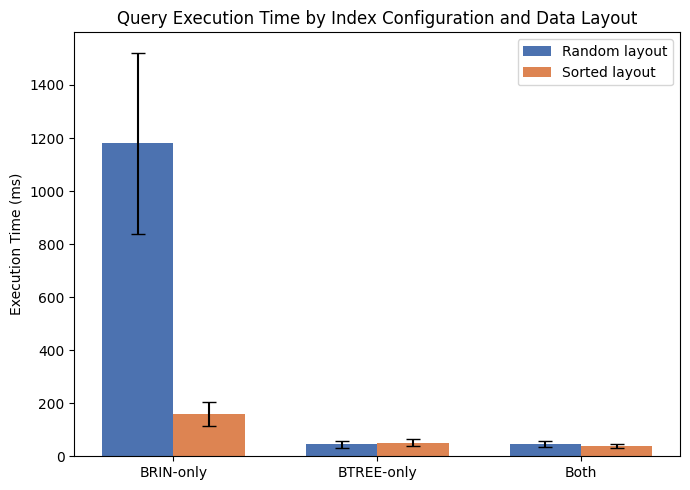

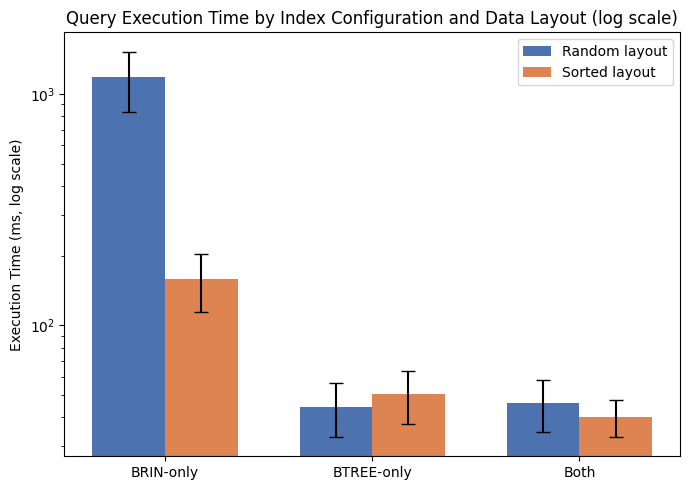

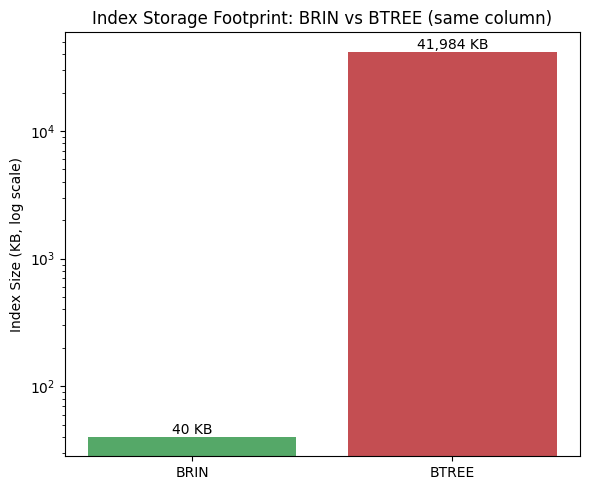

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================================================
# BRIN vs BTREE vs Coexisting Index Benchmark — TPC-H lineitem (SF1)
# Run this top-to-bottom in Google Colab. Each "# %%" marks a natural cell
#
#
# ==========================================================================

# %% [1] Install PostgreSQL and build tools inside the Colab VM
!apt-get -qq update
!apt-get -qq install -y postgresql postgresql-contrib build-essential git > /dev/null
!service postgresql start

# %% [2] Create the database and a password-auth superuser role
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"
!sudo -u postgres createdb tpch_test

# %% [3] Build the official TPC-H data generator (dbgen) and generate SF1 lineitem
!git clone --depth 1 https://github.com/electrum/tpch-dbgen.git
%cd tpch-dbgen
!cp makefile.suite Makefile
!sed -i 's/^CC .*=.*/CC = gcc/' Makefile
!sed -i 's/^DATABASE.*=.*/DATABASE = POSTGRESQL/' Makefile
!sed -i 's/^MACHINE.*=.*/MACHINE = LINUX/' Makefile
!sed -i 's/^WORKLOAD.*=.*/WORKLOAD = TPCH/' Makefile
!make
# -s 1 = scale factor 1 (~6,001,215 lineitem rows); -T L = lineitem table only
!./dbgen -s 1 -T L -f
!sed -i 's/|$//' lineitem.tbl   # strip dbgen's trailing pipe delimiter
!wc -l lineitem.tbl
%cd ..

# %% [4] Load into PostgreSQL and build the two physical layouts
import subprocess

def run_psql(sql, db="tpch_test"):
    """Run a SQL string against tpch_test as the postgres OS user and return stdout."""
    result = subprocess.run(
        ["sudo", "-u", "postgres", "psql", "-d", db, "-c", sql],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
    return result.stdout

ddl = """
DROP TABLE IF EXISTS lineitem_stage, lineitem_sorted, lineitem_random;
CREATE TABLE lineitem_stage (
    l_orderkey bigint, l_partkey bigint, l_suppkey bigint, l_linenumber integer,
    l_quantity numeric(15,2), l_extendedprice numeric(15,2), l_discount numeric(15,2),
    l_tax numeric(15,2), l_returnflag char(1), l_linestatus char(1),
    l_shipdate date, l_commitdate date, l_receiptdate date,
    l_shipinstruct char(25), l_shipmode char(10), l_comment varchar(44)
);
"""
print(run_psql(ddl))

!sudo -u postgres psql -d tpch_test -c "\\COPY lineitem_stage FROM 'tpch-dbgen/lineitem.tbl' WITH (FORMAT csv, DELIMITER '|');"

layout_sql = """
CREATE TABLE lineitem_sorted AS SELECT * FROM lineitem_stage ORDER BY l_shipdate;
CREATE TABLE lineitem_random AS SELECT * FROM lineitem_stage ORDER BY random();
DROP TABLE lineitem_stage;
VACUUM ANALYZE lineitem_sorted;
VACUUM ANALYZE lineitem_random;
"""
for stmt in layout_sql.strip().split(";"):
    if stmt.strip():
        print(run_psql(stmt + ";"))

# Sanity check: verify physical clustering actually differs before trusting any timing result
print(run_psql("""
SELECT tablename, correlation FROM pg_stats
WHERE tablename IN ('lineitem_sorted','lineitem_random') AND attname='l_shipdate';
"""))

# %% [5] Helpers: run EXPLAIN N times, parse the plan for real metrics, and
# reset caches between configurations
import re
import random
import statistics
import subprocess

QUERY = """EXPLAIN (ANALYZE, BUFFERS) SELECT COUNT(*) FROM {table}
WHERE l_shipdate BETWEEN '1995-01-01' AND '1995-03-31';"""

N_REPEATS = 10  # bumped from 3 -> 10 for a more reliable mean/SD

def parse_explain_metrics(plan_text):
    """
    Pull the metrics an EXPLAIN (ANALYZE, BUFFERS) table paper would want
    (planning time, buffers, workers, heap fetches, cost estimate, rows
    scanned, which scan type the planner actually chose) directly out of the
    real plan text, rather than inventing them. Any field that isn't present
    in a given plan (e.g. Heap Fetches only appears for index-only scans)
    comes back as None so it's obvious in the output what wasn't observed,
    instead of silently defaulting to 0 or some other value.
    """
    m = {}

    def find_float(pattern):
        mm = re.search(pattern, plan_text)
        return float(mm.group(1)) if mm else None

    def find_int(pattern):
        mm = re.search(pattern, plan_text)
        return int(mm.group(1)) if mm else None

    m['execution_time_ms'] = find_float(r"Execution Time:\s*([\d.]+)\s*ms")
    m['planning_time_ms']  = find_float(r"Planning Time:\s*([\d.]+)\s*ms")
    m['workers_launched']  = find_int(r"Workers Launched:\s*(\d+)")
    m['heap_fetches']      = find_int(r"Heap Fetches:\s*(\d+)")

    buf = re.search(r"Buffers:\s*shared hit=(\d+)(?:\s+read=(\d+))?", plan_text)
    m['buffers_shared_hit']  = int(buf.group(1)) if buf else None
    m['buffers_shared_read'] = int(buf.group(2)) if (buf and buf.group(2)) else (0 if buf else None)

    # Total cost of the top-level plan node (first "cost=A..B" occurrence)
    cost = re.search(r"cost=[\d.]+\.\.([\d.]+)", plan_text)
    m['cost_estimate'] = float(cost.group(1)) if cost else None

    # Rows/loops from the deepest node reported (last "rows=X loops=Y" match
    # in the printed plan, since child/leaf nodes print below their parents)
    row_matches = re.findall(r"actual time=[\d.]+\.\.[\d.]+ rows=(\d+) loops=(\d+)", plan_text)
    if row_matches:
        m['rows_scanned'], m['scan_loops'] = int(row_matches[-1][0]), int(row_matches[-1][1])
    else:
        m['rows_scanned'], m['scan_loops'] = None, None

    # Which scan node the planner actually used for this run (most specific
    # match first, since e.g. "Bitmap Heap Scan" also contains "Scan")
    scan_type = None
    for kw in ["Parallel Bitmap Heap Scan", "Bitmap Heap Scan",
               "Parallel Index Only Scan", "Index Only Scan",
               "Parallel Index Scan", "Index Scan",
               "Parallel Seq Scan", "Seq Scan"]:
        if kw in plan_text:
            scan_type = kw
            break
    m['scan_type'] = scan_type

    # Partial Aggregate node's own completion time, when present (parallel
    # plans only) — this is what the example table called "Partial
    # Aggregate Time"
    pa = re.search(r"Partial Aggregate[^\n]*actual time=[\d.]+\.\.([\d.]+)", plan_text)
    m['partial_aggregate_time_ms'] = float(pa.group(1)) if pa else None

    return m

def timed_runs(table, n=N_REPEATS):
    times = []
    plans = []
    metrics = []
    for _ in range(n):
        out = run_psql(QUERY.format(table=table))
        mt = re.search(r"Execution Time:\s*([\d.]+)\s*ms", out)
        if mt:
            times.append(float(mt.group(1)))
        plans.append(out)
        metrics.append(parse_explain_metrics(out))
    return times, plans, metrics

def index_size(indexname):
    out = run_psql(f"SELECT pg_size_pretty(pg_relation_size('{indexname}'));")
    lines = [l.strip() for l in out.splitlines() if l.strip() and "pg_size_pretty" not in l and "-" not in l.replace("kB","").replace("MB","")]
    return lines[0] if lines else "?"

def reset_caches():
    """
    Reset PostgreSQL's shared_buffers by restarting the server, and try to drop
    the OS page cache too. This exists specifically to remove the test-order /
    cache-warmth confound: previously, whichever configuration ran last always
    benefited from a warmer cache built up by the configurations before it,
    which made it look faster regardless of whether it actually was.
    Dropping the OS page cache requires root and may not be permitted inside
    Colab's container; if it fails, we still get the shared_buffers reset,
    which is the bigger effect, and we say so rather than hide the shortfall.
    """
    subprocess.run(["service", "postgresql", "restart"], capture_output=True)
    import time
    time.sleep(2)
    try:
        subprocess.run(["sync"], check=True)
        result = subprocess.run(
            "echo 3 > /proc/sys/vm/drop_caches", shell=True, capture_output=True, text=True
        )
        if result.returncode != 0:
            print("  (note: could not drop OS page cache in this environment, "
                  "shared_buffers was reset but the OS file cache may retain some warmth)")
    except Exception:
        print("  (note: OS page cache drop not permitted here; shared_buffers reset only)")

# %% [6] Run all repetitions FULLY INTERLEAVED, not just block-randomized
#

results = {}
all_metrics = {}
run_order_log = {}

configs_template = ["BRIN-only", "BTREE-only", "Both"]

def ensure_config(layout, table, config):
    if config == "BRIN-only":
        run_psql(f"DROP INDEX IF EXISTS idx_{layout}_btree;")
        run_psql(f"CREATE INDEX IF NOT EXISTS idx_{layout}_brin ON {table} USING brin (l_shipdate);")
    elif config == "BTREE-only":
        run_psql(f"DROP INDEX IF EXISTS idx_{layout}_brin;")
        run_psql(f"CREATE INDEX IF NOT EXISTS idx_{layout}_btree ON {table} USING btree (l_shipdate);")
    elif config == "Both":
        run_psql(f"CREATE INDEX IF NOT EXISTS idx_{layout}_brin ON {table} USING brin (l_shipdate);")
        run_psql(f"CREATE INDEX IF NOT EXISTS idx_{layout}_btree ON {table} USING btree (l_shipdate);")

for table, layout in [("lineitem_random", "random"), ("lineitem_sorted", "sorted")]:
    results[(layout, "BRIN-only")] = []
    results[(layout, "BTREE-only")] = []
    results[(layout, "Both")] = []
    all_metrics[(layout, "BRIN-only")] = []
    all_metrics[(layout, "BTREE-only")] = []
    all_metrics[(layout, "Both")] = []
    round_orders = []

    for round_i in range(N_REPEATS):
        order = configs_template.copy()
        random.shuffle(order)
        round_orders.append(order)

        for config in order:
            reset_caches()
            ensure_config(layout, table, config)
            t, _, m = timed_runs(table, n=1)  # exactly one timed query this round
            results[(layout, config)].extend(t)
            all_metrics[(layout, config)].extend(m)
            print(f"  [{layout} round {round_i+1}/{N_REPEATS}] {config}: {t}  scan_type={m[0]['scan_type']}")

    run_order_log[layout] = round_orders
    print(f"\n=== {layout} layout: {N_REPEATS} rounds, each independently shuffled ===")

    # Ensure both indexes exist at the end of this layout's loop so index size
    # can be measured reliably, regardless of which configuration ran last
    # (fixes the bug where idx_random_btree could be missing at measurement
    # time if BRIN-only happened to be the final configuration tested).
    run_psql(f"CREATE INDEX IF NOT EXISTS idx_{layout}_brin ON {table} USING brin (l_shipdate);")
    run_psql(f"CREATE INDEX IF NOT EXISTS idx_{layout}_btree ON {table} USING btree (l_shipdate);")

print("\nRound-by-round run order used per layout (record in the paper's methodology):")
print(run_order_log)

# Index sizes (kept as strings like "40 kB" / "41 MB" from Postgres); both
# indexes are guaranteed to exist at this point regardless of run order.
brin_size = run_psql("SELECT pg_size_pretty(pg_relation_size('idx_random_brin'));")
btree_size = run_psql("SELECT pg_size_pretty(pg_relation_size('idx_random_btree'));")
print("BRIN index size:", brin_size)
print("BTREE index size:", btree_size)

# %% [6b] Detailed per-metric table, averaged across the 10 rounds, per layout
# This is what a table like "Metric | BRIN | BTREE | Combined" in the paper
# should be built from — every number below comes from parsing real EXPLAIN
# (ANALYZE, BUFFERS) output, not from a template.
def avg_metric(metric_list, key):
    vals = [d[key] for d in metric_list if d.get(key) is not None]
    return round(statistics.mean(vals), 2) if vals else None

def most_common(metric_list, key):
    vals = [d[key] for d in metric_list if d.get(key) is not None]
    if not vals:
        return None
    return statistics.mode(vals)

METRIC_KEYS = [
    ("execution_time_ms", "Execution Time (ms)"),
    ("planning_time_ms", "Planning Time (ms)"),
    ("buffers_shared_hit", "Buffers: Shared Hit"),
    ("buffers_shared_read", "Buffers: Shared Read"),
    ("workers_launched", "Workers Launched"),
    ("rows_scanned", "Rows Scanned (leaf node)"),
    ("heap_fetches", "Heap Fetches"),
    ("cost_estimate", "Cost Estimate"),
    ("partial_aggregate_time_ms", "Partial Aggregate Time (ms)"),
]

for layout in ["random", "sorted"]:
    print(f"\n=== Detailed metric table, {layout} layout (mean across {N_REPEATS} rounds) ===")
    header = f"{'Metric':32s} | {'BRIN only':>12s} | {'BTREE only':>12s} | {'Both':>12s}"
    print(header)
    print("-" * len(header))
    for key, label in METRIC_KEYS:
        row = [avg_metric(all_metrics[(layout, cfg)], key) for cfg in configs_template]
        print(f"{label:32s} | {str(row[0]):>12s} | {str(row[1]):>12s} | {str(row[2]):>12s}")
    scan_row = [most_common(all_metrics[(layout, cfg)], "scan_type") for cfg in configs_template]
    print(f"{'Most common scan type':32s} | {str(scan_row[0]):>12s} | {str(scan_row[1]):>12s} | {str(scan_row[2]):>12s}")

# %% [7] Summarize into a table (mean +/- SD) — this is what should go in the paper
summary = {}
for key, times in results.items():
    summary[key] = (statistics.mean(times), statistics.stdev(times) if len(times) > 1 else 0.0)

for key, (mean, sd) in summary.items():
    print(f"{key}: {mean:.2f} ms +/- {sd:.2f} ms  (n={len(results[key])})")



# %% [8] Figure 1 — Execution time comparison, grouped bar chart (random vs sorted)
import matplotlib.pyplot as plt
import numpy as np

configs = ["BRIN-only", "BTREE-only", "Both"]
random_means = [summary[("random", c)][0] for c in configs]
random_sds   = [summary[("random", c)][1] for c in configs]
sorted_means = [summary[("sorted", c)][0] for c in configs]
sorted_sds   = [summary[("sorted", c)][1] for c in configs]

x = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, random_means, width, yerr=random_sds, capsize=5, label="Random layout", color="#4C72B0")
ax.bar(x + width/2, sorted_means, width, yerr=sorted_sds, capsize=5, label="Sorted layout", color="#DD8452")
ax.set_ylabel("Execution Time (ms)")
ax.set_title("Query Execution Time by Index Configuration and Data Layout")
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
plt.tight_layout()
plt.savefig("fig1_execution_time.png", dpi=200)
plt.show()

# %% [9] Figure 2 — same data on a log scale (random/BRIN-only dwarfs everything else linearly)
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, random_means, width, yerr=random_sds, capsize=5, label="Random layout", color="#4C72B0")
ax.bar(x + width/2, sorted_means, width, yerr=sorted_sds, capsize=5, label="Sorted layout", color="#DD8452")
ax.set_yscale("log")
ax.set_ylabel("Execution Time (ms, log scale)")
ax.set_title("Query Execution Time by Index Configuration and Data Layout (log scale)")
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
plt.tight_layout()
plt.savefig("fig2_execution_time_logscale.png", dpi=200)
plt.show()

# %% [10] Figure 3 — Index storage footprint (BRIN vs BTREE), log scale, in KB
import re as _re

def size_to_kb(size_str):
    """Parse a Postgres pg_size_pretty string like '40 kB' or '41 MB' into KB."""
    m = _re.search(r"([\d.]+)\s*(kB|MB|GB|bytes)", size_str)
    if not m:
        return None
    val, unit = float(m.group(1)), m.group(2)
    return {"bytes": val / 1024, "kB": val, "MB": val * 1024, "GB": val * 1024 * 1024}[unit]

brin_kb = size_to_kb(brin_size) or 40
btree_kb = size_to_kb(btree_size) or 41 * 1024

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["BRIN", "BTREE"], [brin_kb, btree_kb], color=["#55A868", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Index Size (KB, log scale)")
ax.set_title("Index Storage Footprint: BRIN vs BTREE (same column)")
for b, v in zip(bars, [brin_kb, btree_kb]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f} KB", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("fig3_index_size.png", dpi=200)
plt.show()

# %% [11] Download the figures to insert into the Word document
from google.colab import files
for f in ["fig1_execution_time.png", "fig2_execution_time_logscale.png", "fig3_index_size.png"]:
    files.download(f)

